In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import math
from statsmodels.tsa.stattools import adfuller
import seaborn as sns


In [2]:
data=pd.read_csv('time-series.csv')
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9
0,Q1,6790.643698,6598.952202,6608.527173,6765.914014,6992.949003,6931.539,7161.240869,6981.304105
1,Q2,7081.709669,6789.414723,6895.838545,7050.508939,7155.206969,7075.445,7373.832383,7339.981903
2,Q3,7188.893596,6986.330400,7025.162033,7066.270724,7129.545542,7079.719,7242.259002,7043.345329
3,Q4,7679.102564,7483.094657,7510.212380,7600.148193,7714.398010,7677.571,7922.636157,7707.159526
4,Q5,1150.000000,995.000000,1083.000000,1465.000000,1079.000000,948.000,1298.000000,1763.000000


In [3]:
df=data[['V1','V3']]
df.head()

,V1,V3
0,Q1,6598.952202
1,Q2,6789.414723
2,Q3,6986.330400
3,Q4,7483.094657
4,Q5,995.000000


In [4]:
df.set_index('V1', inplace=True)
df

,V3
V1,
Q1,6598.952202
Q2,6789.414723
Q3,6986.330400
Q4,7483.094657
Q5,995.000000
...,...
Q23996,2170.000000
Q23997,10180.000000
Q23998,10180.000000


In [5]:
df.describe()

,V3
count,24000.000000
mean,5863.121355
std,4546.770194
min,72.800000
25%,2167.900024
50%,4557.702970
75%,9050.000000
max,78103.000000


In [6]:
df.isnull().sum()

V3    0
dtype: int64

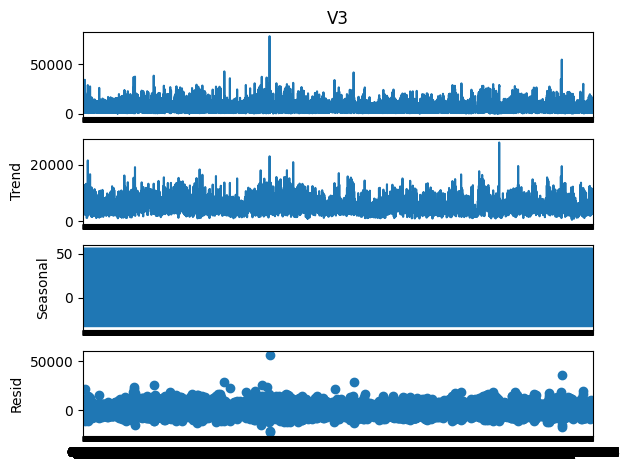

In [7]:
decomposition = seasonal_decompose(df['V3'], model='additive', period=4)  # Quarterly frequency
decomposition.plot()
plt.show()

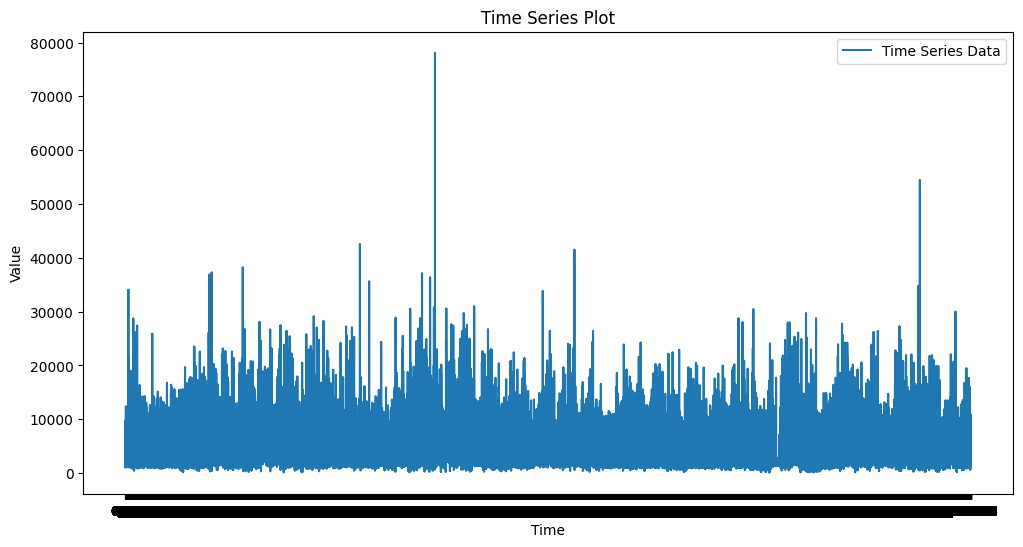

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df.iloc[:, 0], label='Time Series Data')
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [9]:
# Check stationarity using Augmented Dickey-Fuller Test
adf_test = adfuller(df.iloc[:, 0])
print("\nAugmented Dickey-Fuller Test:")
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"   {key}: {value}")

if adf_test[1] > 0.05:
    print("\nThe data is not stationary. Consider differencing or transformations.")
else:
    print("\nThe data is stationary.")


Augmented Dickey-Fuller Test:
ADF Statistic: -15.362434098721323
p-value: 3.597616190802691e-28
Critical Values:
   1%: -3.430623046132129
   5%: -2.861660677890782
   10%: -2.5668342333532155

The data is stationary.


In [10]:
split_index = int(len(df) * 0.7)

# Split the data
train = df.iloc[:split_index]
test = df.iloc[split_index:]

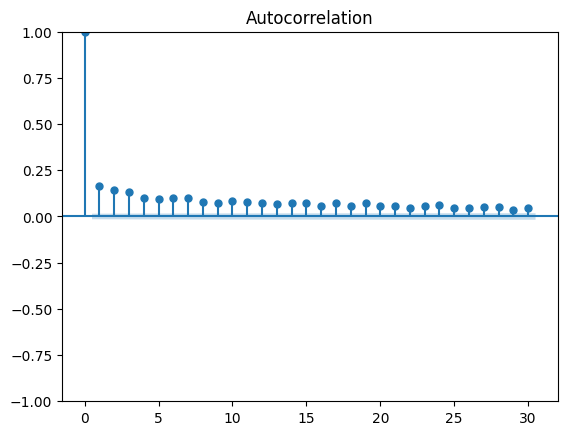

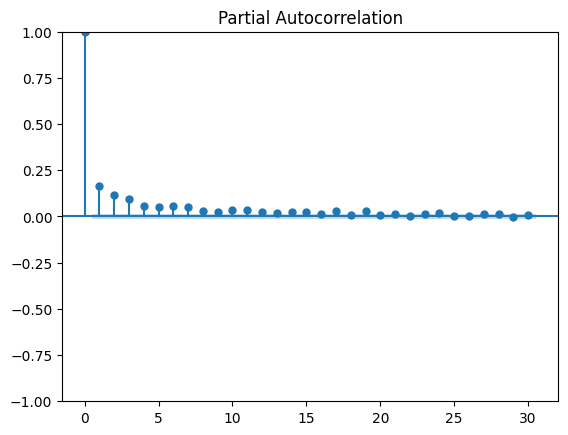

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
plot_acf(train['V3'], lags=30)
plt.show()

plot_pacf(train['V3'], lags=30)
plt.show()


In [19]:
from statsmodels.tsa.arima.model import ARIMA

ar_model = ARIMA(train['V3'], order=(1, 0, 1))  
ar_fit = ar_model.fit()
print(ar_fit.summary())


c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq

                               SARIMAX Results                                
Dep. Variable:                     V3   No. Observations:                16800
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -164877.286
Date:                Sat, 04 Jan 2025   AIC                         329762.572
Time:                        11:52:01   BIC                         329793.488
Sample:                             0   HQIC                        329772.773
                              - 16800                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5983.9614     91.454     65.431      0.000    5804.714    6163.209
ar.L1          0.9465      0.006    169.506      0.000       0.936       0.957
ma.L1         -0.8613      0.008   -107.849      0.0

In [22]:
from statsmodels.tsa.arima.model import ARIMA

ar_model2 = ARIMA(train['V3'], order=(2, 0, 1))  
ar_fit2 = ar_model2.fit()
print(ar_fit2.summary())


c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq

                               SARIMAX Results                                
Dep. Variable:                     V3   No. Observations:                16800
Model:                 ARIMA(2, 0, 1)   Log Likelihood             -164867.717
Date:                Sat, 04 Jan 2025   AIC                         329745.434
Time:                        11:57:38   BIC                         329784.079
Sample:                             0   HQIC                        329758.185
                              - 16800                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5983.9614     99.688     60.027      0.000    5788.577    6179.346
ar.L1          1.0051      0.010     96.177      0.000       0.985       1.026
ar.L2         -0.0425      0.008     -5.592      0.0

In [26]:
fitted_values = ar_fit2.fittedvalues

<Axes: xlabel='V1'>

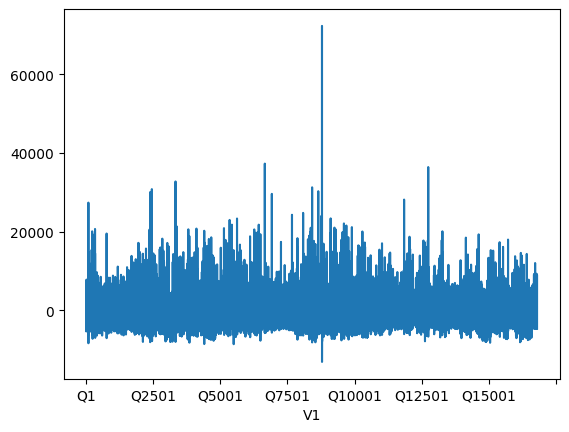

In [23]:
ar_fit2.resid.plot()

In [24]:
prediction=ar_fit2.forecast(len(test)+4)

c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\sreen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


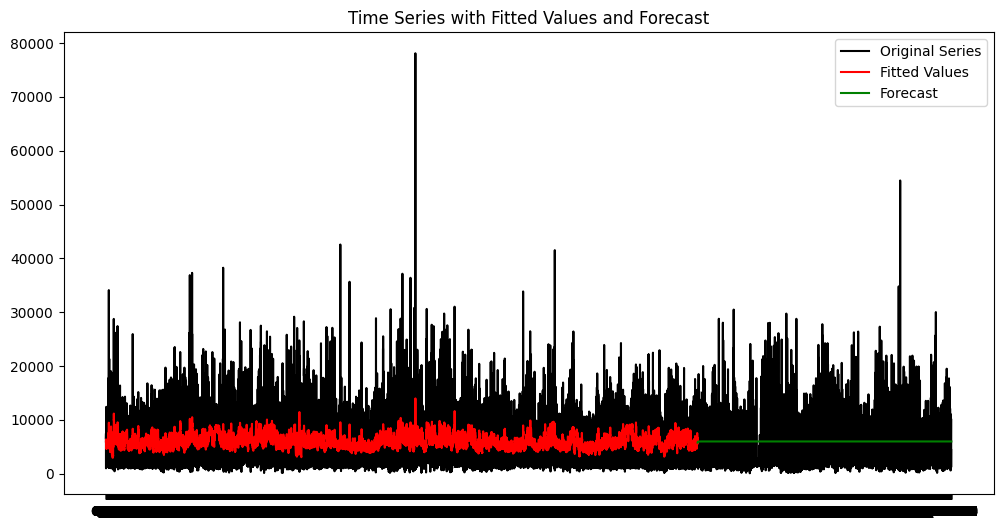

In [27]:
plt.figure(figsize=(12,6))
plt.plot(df['V3'], color="black", label="Original Series")
plt.plot(fitted_values, color="red", label="Fitted Values")
plt.plot(prediction, color="green", label="Forecast")
plt.legend()
plt.title("Time Series with Fitted Values and Forecast")
plt.show()